# 🧠 Multi-Layer Perceptron Workshop

## 👥 Group Information

**Group Name:** Final_Project_Group 1  

**Members:**
- Haibo Yuan (Student ID: 9010929)
- Ce Chen (Student ID: 9007166)
- Zhuoran Zhang (Student ID: 9048508)

---

## 📌 Workshop Objective

This workshop focuses on understanding how Multi-Layer Perceptrons (MLPs) work by implementing forward propagation and backpropagation using NumPy. The goal is to build a deeper intuition of neural network training and optimization.

---


# Foundations of Machine Learning: An Introduction to Neural Networks & MLPs
This notebook is a tutorial on **Neural Networks**. It starts with the basic building block, the "neuron," and builds its way up to a more powerful model capable of solving complex problems: the **Multi-Layered Perceptron (MLP)**.

At the end is a workshop on classifying handwritten digits from the MNIST dataset.

You will be asked to compare the Keras, PyTorch and TensorFlow implementations in terms of accuracy and speed.

<br/>
<br/>

### 💡 Additional Reading Material

These other tutorials come from the Course Notebooks Repository:

> In-depth: 
[**Multiclass Classification - A Simple Keras Model (MNIST)**](https://github.com/CSCN8010/CSCN8010/blob/main/dl_class_notebooks/03A_minimal_mnist_keras.ipynb)

> In-depth: 
[**Train and Aave a Simple Keras Model (MNIST)**](https://github.com/CSCN8010/CSCN8010/blob/main/dl_class_notebooks/03D_keras_checkpoints_save_model.ipynb)

> In-depth: 
[**Loading a pre-trained Keras model and classifying digits (MNIST)**](https://github.com/CSCN8010/CSCN8010/blob/main/dl_class_notebooks/03B_load_minimal_mnist_model.ipynb)  

<br/>
<br/>

***



### 1. The Inspiration: From Biological to Artificial Neurons

At its core, the field of neural networks is inspired by the human brain. We'll start by understanding the basic concept of a neuron.

#### **Key Concepts: The Neuron**

- An artificial intelligence (AI) system is designed to perceive its environment and act accordingly. 
- Neural networks are the "brain" of these systems.
- The simplest neural network is a **perceptron**, which consists of a single artificial neuron.
- The concept of an artificial neuron is modeled after a biological one.

* A **biological neuron** receives electrical signals through its *dendrites*. If the combined strength of these signals surpasses a certain threshold, the neuron "fires," sending an output signal through its *synapses* to other neurons.
* An **artificial neuron** works similarly. It receives multiple *inputs*, performs a calculation, and if the result exceeds a threshold, it produces an *output*.



### 2. The Perceptron: A Single Neuron in Action

Let's break down the mechanics of that single artificial neuron, the perceptron.

#### **Presentation: Anatomy of a Perceptron**

A perceptron operates on a simple principle: it takes a set of inputs, weighs them based on their importance, sums them up, and then uses an **activation function** to decide whether to "fire" and produce an output.

Here are the key components:

1.  **Inputs ($x$)**: These are the features of your data. For example, if you're predicting a house price, inputs could be the size, number of rooms, and age of the house. Each input is a feature that contributes to the final decision.

2.  **Weights ($w$)**: Not all inputs are equally important. Each input feature ($x_i$) is assigned a weight ($w_i$) that reflects its importance in the decision-making process. A higher weight amplifies an input's effect, while a lower weight diminishes it. The network learns these weights during training.

3.  **Weighted Sum ($z$)**: The neuron calculates the sum of all inputs multiplied by their corresponding weights. We also add a **bias ($b$)**, which is like the y-intercept in a linear equation. It allows us to shift the activation function, giving the model more flexibility. The formula is:
    $$z = (x_1w_1 + x_2w_2 + ... + x_nw_n) + b = \sum_{i=1}^{n} x_i w_i + b$$

4.  **Activation Function ($f(z)$)**: This is the decision-making unit of the neuron. It takes the weighted sum ($z$) as input and transforms it into the final output. For a simple step function, the output is either 0 or 1. This introduces non-linearity, which is crucial for learning complex patterns.


### ✍️ Student Understanding

The perceptron represents the fundamental unit of a neural network. It performs a linear combination of inputs and weights, followed by an activation function.

The formula \( z = \sum x_i w_i + b \) is essential because it defines how the model transforms input features into a signal that can be processed further.

The activation function then introduces non-linearity, allowing the model to learn complex patterns beyond simple linear relationships.


#### **Building a Perceptron with Python**

Let's build a simple perceptron from scratch using NumPy to see these concepts in code. We'll use a simple "step" activation function.


In [ ]:
import numpy as np

# A simple perceptron class
class Perceptron:
    """A single neuron model."""

    def __init__(self, num_inputs):
        """
        Initializes the perceptron.
        Args:
            num_inputs (int): The number of input features.
        """
        # Initialize weights with small random numbers. Bias is the last weight.
        self.weights = np.random.rand(num_inputs + 1)
        print(f"Initialized weights: {self.weights}")

    def step_function(self, z):
        """The activation function."""
        return 1 if z >= 0 else 0

    def predict(self, inputs):
        """
        Calculates the weighted sum and passes it to the activation function.
        Args:
            inputs (list or np.array): The input features.
        Returns:
            int: The binary output (0 or 1).
        """
        # Add the bias input (always 1)
        inputs_with_bias = np.append(inputs, 1)

        # Calculate the weighted sum: z = sum(x_i * w_i)
        z = np.dot(inputs_with_bias, self.weights)
        print(f"Inputs (with bias): {inputs_with_bias}")
        print(f"Weighted Sum (z): {z:.4f}")

        # Apply the activation function
        output = self.step_function(z)
        print(f"Output: {output}")
        return output

# --- Let's test our Perceptron! ---
# Create a perceptron that takes 2 inputs
p = Perceptron(num_inputs=2)

# Define some sample inputs
sample_inputs = np.array([0.8, 0.5])

# Make a prediction
prediction = p.predict(sample_inputs)
print(f"\nFinal prediction for inputs {sample_inputs} is: {prediction}")


Initialized weights: [0.1905556  0.66940328 0.76977578]
Inputs (with bias): [0.8 0.5 1. ]
Weighted Sum (z): 1.2569
Output: 1

Final prediction for inputs [0.8 0.5] is: 1


### ✍️ Code Explanation: Perceptron Implementation

In this implementation, we created a simple perceptron model using NumPy.

- The weights are initialized randomly, including an additional weight for the bias.
- The input vector is extended by adding a bias term (1).
- The weighted sum is calculated using the dot product: \( z = w \cdot x + b \).
- A step activation function is applied to produce a binary output (0 or 1).

This demonstrates how a single artificial neuron processes inputs and produces a decision.


### 3. Activation Functions: Adding Non-Linearity

[cite_start]A single perceptron with a step function can only separate data with a single straight line[cite: 178]. To learn truly complex patterns, like those in images or speech, we need more sophisticated activation functions that introduce **non-linearity**.

#### **Presentation: Common Activation Functions**

While there are many activation functions, three are particularly common and important to know. [cite_start]The PDF specifically mentions **ReLU** and **softmax** as popular choices[cite: 280].

1.  **Sigmoid (or Logistic)**
    * **Formula**: $\sigma(z) = \frac{1}{1 + e^{-z}}$
    * **Output Range**: (0, 1)
    * **Use Case**: Excellent for binary classification problems where the output needs to be a probability.
    * **Downside**: Suffers from the "vanishing gradient" problem, which can slow down learning in deep networks.

2.  **Tanh (Hyperbolic Tangent)**
    * **Formula**: $\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$
    * **Output Range**: (-1, 1)
    * **Use Case**: Similar to sigmoid but is "zero-centered," which can sometimes help models learn faster.
    * **Downside**: Also suffers from the vanishing gradient problem.

3.  **ReLU (Rectified Linear Unit)**
    * **Formula**: $R(z) = \max(0, z)$
    * **Output Range**: [0, $\infty$)
    * **Use Case**: The most popular activation function for hidden layers in deep learning. It's computationally very efficient and helps mitigate the vanishing gradient problem.
    * **Downside**: Can "die" if a neuron's output consistently becomes zero, preventing weight updates.


### ✍️ Student Understanding

Activation functions introduce non-linearity into the model, allowing neural networks to learn complex patterns beyond simple linear relationships.

Without activation functions, stacking multiple layers would still behave like a single linear model.

Among the common activation functions:
- Sigmoid is useful for probability outputs.
- Tanh is zero-centered, which can improve training.
- ReLU is widely used due to its efficiency and ability to reduce the vanishing gradient problem.

In this workshop, ReLU is particularly important because it is commonly used in modern deep learning models.


#### **Visualizing Activation Functions**

Let's plot these functions to understand their behavior.


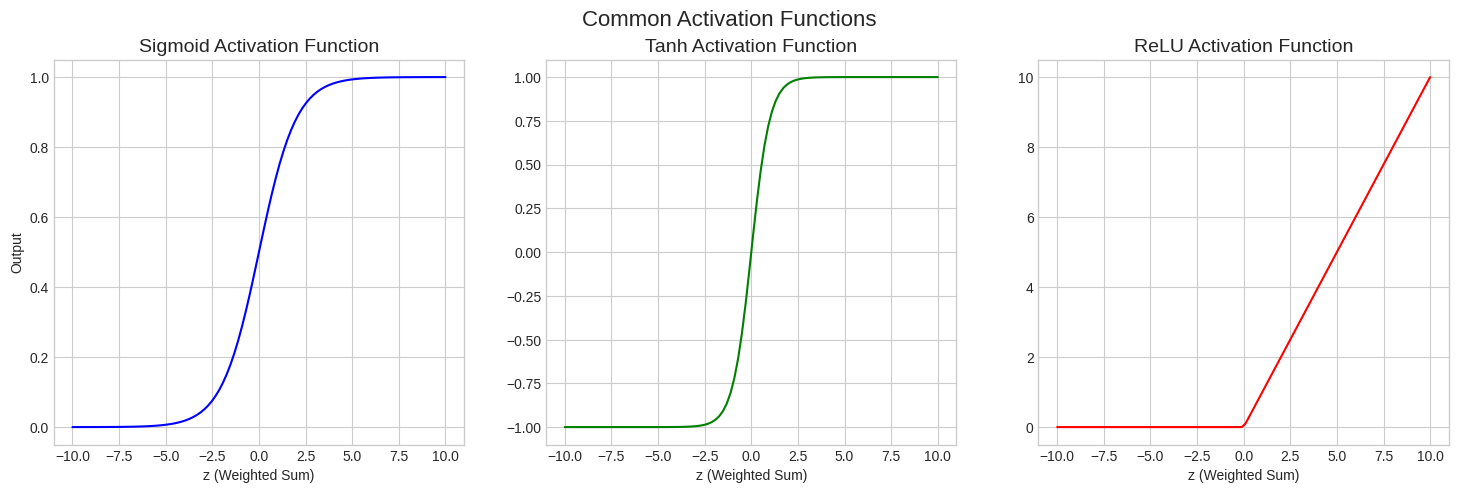

In [2]:

import numpy as np
import matplotlib.pyplot as plt

# Define the input range
z = np.linspace(-10, 10, 100)

# Define the activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

# Plotting
plt.style.use('seaborn-v0_8-whitegrid')
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].plot(z, sigmoid(z), color='blue')
axs[0].set_title('Sigmoid Activation Function', fontsize=14)
axs[0].set_xlabel('z (Weighted Sum)')
axs[0].set_ylabel('Output')

axs[1].plot(z, tanh(z), color='green')
axs[1].set_title('Tanh Activation Function', fontsize=14)
axs[1].set_xlabel('z (Weighted Sum)')

axs[2].plot(z, relu(z), color='red')
axs[2].set_title('ReLU Activation Function', fontsize=14)
axs[2].set_xlabel('z (Weighted Sum)')

plt.suptitle('Common Activation Functions', fontsize=16)
plt.show()


### ✍️ Visualization Analysis

From the plots, we can observe that:

- The **sigmoid function** outputs values between 0 and 1, making it suitable for probability-based tasks, but it saturates for large positive or negative inputs.
- The **tanh function** outputs values between -1 and 1 and is centered around zero, which can help improve convergence during training.
- The **ReLU function** outputs zero for negative inputs and increases linearly for positive values, making it computationally efficient and widely used in deep neural networks.

These differences explain why ReLU is commonly used in hidden layers of modern neural networks.
ReLU helps maintain gradient flow during training, which reduces the vanishing gradient problem compared to sigmoid and tanh.


### 4. From One to Many: The Multi-Layer Perceptron (MLP)

A single neuron is limited. To solve complex, **non-linear problems**, we need to combine many neurons into a network.

#### **MLP Architecture**

A very common architecture is to stack neurons in layers. This creates a **Multi-Layer Perceptron (MLP)**. An MLP has three types of layers:

1.  **Input Layer**: This layer receives the initial feature vector. It doesn't perform calculations; it simply passes the data to the first hidden layer.
2.  **Hidden Layers**: These are the layers between the input and output. This is where most of the learning happens. Each neuron in a hidden layer receives outputs from the previous layer, performs the `weighted sum -> activation` calculation, and passes its output to the next layer. Networks with two or more hidden layers are often called **deep neural networks**.
3.  **Output Layer**: This is the final layer that produces the model's prediction. The number of neurons and the activation function in this layer depend on the problem you're solving (e.g., one neuron with a sigmoid for binary classification, or multiple neurons with a softmax function for multi-class classification).

In an MLP, layers are typically **fully connected**, meaning every neuron in one layer is connected to every neuron in the next layer.


### ✍️ Student Understanding

A Multi-Layer Perceptron (MLP) extends the idea of a single perceptron by stacking multiple layers of neurons.

Each layer performs a transformation of the data using a weighted sum followed by an activation function. The output of one layer becomes the input of the next.

This layered structure allows the model to learn complex, non-linear relationships that cannot be captured by a single neuron.

In this workshop, we will implement this process step by step to understand how information flows forward through the network.

This architecture forms the foundation of deep learning models used in real-world applications such as image and speech recognition.


### 5. The Learning Process: Feedforward & Backpropagation

How does an MLP actually *learn*? It's a two-part process that is repeated many times: **Feedforward** to make a prediction, and **Backpropagation** to correct errors.

#### **The Learning Loop**

**Step 1: Feedforward (Making a Prediction)**

This is the process of information flowing forward through the network.

1.  The input data is fed into the **input layer**.
2.  The data flows to the first **hidden layer**. Each neuron in this layer calculates its weighted sum and applies its activation function.
3.  The outputs of the first hidden layer become the inputs for the second hidden layer, and so on.
4.  This continues until the data reaches the **output layer**, which produces the final prediction ($y'$).

The entire process is a chain of `weighted sum -> activation` calculations, layer by layer, from input to output.

**Step 2: Backpropagation (Learning from Mistakes)**

Once the network makes a prediction ($y'$), we need to see how good it was.

1.  **Compute Error (Loss)**: We compare the network's prediction ($y'$) with the correct, true label ($y$). The difference is the **error**. We use an **error function** (or loss function) like Mean Squared Error or Cross-Entropy to calculate a single score representing how wrong the model was.
    * **Error Calculation**: `error = y - y'` 

2.  **Propagate Error Backwards**: This is the magic of backpropagation. The error is sent backward through the network, from the output layer to the input layer.

3.  **Update Weights**: As the error propagates back, it's used to calculate how much each weight and bias in the network contributed to the total error. The network then adjusts its weights to reduce the error. For instance, if a large weight led to a large error, the network will decrease that weight. This process uses calculus (specifically, an algorithm called **gradient descent**) to find the optimal weight values that minimize the error. For a more in-depth analysis of this method, read the tutorial at [3Blue1Brown - What is Backpropagation Really Doing?](https://www.3blue1brown.com/lessons/backpropagation)

4.  **Repeat**: This entire `feedforward -> backpropagation` cycle is repeated many times (for many **epochs**) with the entire training dataset. With each cycle, the network's weights get a little bit better, and its predictions become more and more accurate.


### ✍️ Student Understanding

The learning process of a neural network consists of two main steps: feedforward and backpropagation.

During feedforward, the input data passes through each layer, where it is transformed using weighted sums and activation functions to produce a prediction.

During backpropagation, the model calculates the error between the predicted output and the true value, and then propagates this error backward through the network. This allows the model to adjust its weights using gradient descent.

This iterative process enables the network to gradually improve its predictions over time.

Backpropagation is essential because it allows the model to learn which parameters contribute most to the error and adjust them accordingly.

## 🔄 Understanding How the Model Compares Predictions to True Labels (Backpropagation Step 2)

During training, your model learns by comparing its **predicted output** to the **correct, true label** that comes from the dataset. This comparison happens **during every epoch**, and it is essential for calculating the **loss** (error), which drives backpropagation.

### ✅ What Happens During Training (Simplified View)

1. **Training Dataset**  
   You start with a dataset consisting of input–output pairs:  
   $$
   (X, y) = \\{(x^{(1)}, y^{(1)}), (x^{(2)}, y^{(2)}), ..., (x^{(n)}, y^{(n)})\\}
   $$
   - $x^{(i)}$ is the input vector (features)
   - $y^{(i)}$ is the correct, true label (target output)

2. **Model Initialization**  
   The model starts with **random weights**.

3. **Epoch Loop**  
   For each epoch:
   - For each mini-batch or training sample:
     1. Feed **input `x`** into the model → get prediction `y_pred`
     2. Compare `y_pred` with the **true label `y_true`**
     3. Compute **loss** using a loss function (e.g., MSE or Cross-Entropy)
     4. Perform **backpropagation** to compute gradients
     5. **Update weights** with an optimizer

### 🧠 Pseudocode: Training Up to Loss Calculation

```python
# Assume: training_data = [(x1, y1), (x2, y2), ..., (xn, yn)]
# x = input vector, y = true label

initialize_model_weights()

for epoch in range(num_epochs):
    for x, y_true in training_data:
        
        # ---- FEEDFORWARD ----
        y_pred = model.forward(x)  # Predict output based on current weights
        
        # ---- COMPARE PREDICTION TO TRUE LABEL ----
        # Step 1: Compute loss (error between prediction and true label)
        loss = loss_function(y_pred, y_true)  # e.g., MSE, Cross-Entropy

        # ---- BACKPROPAGATION ----
        gradients = compute_gradients(loss, model.weights)
        
        # ---- UPDATE WEIGHTS ----
        optimizer.step(model.weights, gradients)
````

### 💬 Where Does `y_true` Come From?

It comes from the **training dataset**, which:

* Is usually prepared as `(X_train, y_train)` arrays
* Or loaded using a **DataLoader** that returns `(x, y)` pairs

During training, for every training example or batch:

* The model uses the **input `x`** to make a prediction
* The **label `y_true`** is passed into the **loss function** to compute how wrong the prediction was


### 🎓 Example (PyTorch Training Loop)

```python
for x_batch, y_true in train_loader:
    y_pred = model(x_batch)                  # Forward pass
    loss = loss_fn(y_pred, y_true)           # Compare prediction to true label
    loss.backward()                          # Backpropagation
    optimizer.step()                         # Update weights
    optimizer.zero_grad()                    # Reset gradients
```

### 📝 To summarize...

* The **true label `y_true`** comes from the training dataset.
* It is compared to the **model’s prediction `y_pred`** inside the loss function.
* The result (error/loss) is backpropagated to update weights and improve predictions.



### ✍️ Student Understanding

This section clarifies how the model learns by comparing its predictions to the true labels during training.

The key idea is that the model does not "know" the correct answer by itself. Instead, it relies on the true labels provided in the dataset to calculate the loss.

By measuring the difference between the predicted output (`y_pred`) and the true label (`y_true`), the model can determine how wrong it is and adjust its weights accordingly through backpropagation.

This process is repeated over many epochs, gradually improving the model’s performance.

The loss function acts as a bridge between prediction and learning by quantifying how far the model is from the correct answer.


### 6. Building an MLP: The Complete Workshop

Now, let's put it all together. We will build, train, and evaluate an MLP to solve a classic machine learning problem: classifying handwritten digits from the MNIST dataset. We'll use the three most popular deep learning libraries: **Keras (with a TensorFlow backend)**, **TensorFlow (Core API)**, and **PyTorch**.

This will show you that while the syntax differs, the core concepts�defining layers, choosing a loss function, and training the model�are universal.

#### **Code Workshop: MNIST Digit Classification**

First, let's load and prepare our data.


In [3]:
import tensorflow as tf
from tensorflow import keras
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

# --- Load and Preprocess Data ---
# Load data for TensorFlow/Keras
(x_train_tf, y_train_tf), (x_test_tf, y_test_tf) = keras.datasets.mnist.load_data()

# Normalize pixel values to be between 0 and 1
x_train_tf = x_train_tf.astype("float32") / 255.0
x_test_tf = x_test_tf.astype("float32") / 255.0

# Flatten the images from 28x28 to 784-element vectors
x_train_flat = x_train_tf.reshape(-1, 784)
x_test_flat = x_test_tf.reshape(-1, 784)

print(f"TensorFlow/Keras Data Shape: {x_train_flat.shape}")

# Load data for PyTorch
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset_pt = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset_pt = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader_pt = torch.utils.data.DataLoader(train_dataset_pt, batch_size=64, shuffle=True)
test_loader_pt = torch.utils.data.DataLoader(test_dataset_pt, batch_size=64, shuffle=False)

print(f"PyTorch Data Loaded. Number of training batches: {len(train_loader_pt)}")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
TensorFlow/Keras Data Shape: (60000, 784)


100%|██████████| 9.91M/9.91M [00:00<00:00, 11.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 337kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.17MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.75MB/s]

PyTorch Data Loaded. Number of training batches: 938


### ✍️ Data Preparation Explanation

In this step, we loaded the MNIST dataset and prepared it for training.

- The pixel values were normalized from the range [0, 255] to [0, 1], which helps improve training stability and convergence.
- The images were reshaped from 28×28 matrices into 784-dimensional vectors to match the input requirements of a fully connected neural network (MLP).
- For PyTorch, we used a DataLoader to handle batching and shuffling of the dataset.

This preprocessing ensures that the data is in the correct format for training MLP models across different frameworks.

Normalization is especially important for neural networks because it helps prevent large gradients and improves optimization performance.


#### **Implementation 1: Keras**

Keras is popular due to its simplicity and user-friendly API. 

> Note the time spent training the model. 

- Tweak the hyperparameters to and test their impact on training speed.
- Analyze the training metrics (on the output). What are `val_accuracy` and `val_loss` ?


In [4]:

# --- 1. Define the Keras Model ---
# This is a sequential model, a simple stack of layers.
model_keras = keras.Sequential([
    # Input layer: 784 inputs (our flattened 28x28 image)
    keras.layers.Input(shape=(784,)),
    # Hidden Layer 1: 128 neurons, ReLU activation
    keras.layers.Dense(128, activation='relu'),
    # Hidden Layer 2: 64 neurons, ReLU activation
    keras.layers.Dense(64, activation='relu'),
    # Output Layer: 10 neurons (for digits 0-9), softmax for multi-class probability
    keras.layers.Dense(10, activation='softmax')
])

# Print a summary of the model architecture
model_keras.summary()

# --- 2. Compile the Model ---
# This step configures the model for training.
model_keras.compile(
    optimizer='adam',  # Adam is an efficient optimization algorithm
    loss='sparse_categorical_crossentropy',  # A common loss function for multi-class classification
    metrics=['accuracy']  # We want to monitor the accuracy
)

# --- 3. Train the Model ---
print("\n--- Training Keras Model ---")
history = model_keras.fit(
    x_train_flat,
    y_train_tf,
    batch_size=64,
    epochs=5,  # An epoch is one full pass through the entire training dataset
    validation_split=0.1 # Use 10% of training data for validation
)

# --- 4. Evaluate the Model ---
print("\n--- Evaluating Keras Model ---")
test_loss, test_acc = model_keras.evaluate(x_test_flat, y_test_tf, verbose=2)
print(f"\nKeras Test Accuracy: {test_acc:.4f}")


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


--- Training Keras Model ---
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9159 - loss: 0.2919 - val_accuracy: 0.9653 - val_loss: 0.1282
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9640 - loss: 0.1183 - val_accuracy: 0.9740 - val_loss: 0.0921
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9759 - loss: 0.0793 - val_accuracy: 0.9785 - val_loss: 0.0726
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9808 - loss: 0.0614 - val_accuracy: 0.9775 - val_loss: 0.0796
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9844 - loss: 0.0490 - val_accuracy: 0.9785 - val_loss: 0.0746

--- Evaluating Keras Model ---
313/313 - 1s - 2ms/step - accuracy: 0.9757 - loss: 0.0816

Keras Test Accuracy: 0.9757


### 📊 Keras Training Analysis

The model achieved a high test accuracy of approximately 97%, which indicates that the MLP performs well on the MNIST classification task.

- **val_accuracy** represents the accuracy of the model on the validation dataset. It shows how well the model generalizes to unseen data during training.
- **val_loss** represents the error on the validation dataset. Lower values indicate better performance.

We can observe that:
- The validation accuracy increases over epochs, showing learning progress.
- The validation loss decreases, indicating the model is improving and not overfitting significantly.

### ✍️ Student Note

The Keras implementation is simple and fast to train. It provides high accuracy with minimal code, making it ideal for rapid prototyping.


#### **Implementation 2: PyTorch**

PyTorch is known for its flexibility and is very popular in research. The structure is more explicit, requiring you to define the model as a class. 

> Note the time spent training the model. 

- Tweak the hyperparameters to and test their impact on training speed.
- Analyze the code. What are `images`, `labels`, `criterion` and `optimizer` ?


In [5]:

# --- 1. Define the PyTorch Model ---
class MLP_PyTorch(nn.Module):
    def __init__(self):
        super(MLP_PyTorch, self).__init__()
        self.flatten = nn.Flatten()
        # Define the sequence of layers
        self.layers = nn.Sequential(
            nn.Linear(28 * 28, 128), # Input -> Hidden 1
            nn.ReLU(),
            nn.Linear(128, 64),      # Hidden 1 -> Hidden 2
            nn.ReLU(),
            nn.Linear(64, 10)        # Hidden 2 -> Output
        )

    def forward(self, x):
        # This defines the feedforward pass
        x = self.flatten(x)
        logits = self.layers(x)
        return logits

model_pt = MLP_PyTorch()
print(model_pt)

# --- 2. Define Loss and Optimizer ---
criterion = nn.CrossEntropyLoss() # Combines LogSoftmax and NLLLoss
optimizer = optim.Adam(model_pt.parameters(), lr=0.001)

# --- 3. Train the Model ---
print("\n--- Training PyTorch Model ---")
model_pt.train() # Set the model to training mode
for epoch in range(5):
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader_pt):
        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model_pt(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader_pt):.4f}")

# --- 4. Evaluate the Model ---
print("\n--- Evaluating PyTorch Model ---")
model_pt.eval() # Set the model to evaluation mode
correct = 0
total = 0
with torch.no_grad(): # We don't need to calculate gradients during evaluation
    for images, labels in test_loader_pt:
        outputs = model_pt(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"PyTorch Test Accuracy: {correct / total:.4f}")


MLP_PyTorch(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

--- Training PyTorch Model ---
Epoch 1, Loss: 0.4080
Epoch 2, Loss: 0.1935
Epoch 3, Loss: 0.1391
Epoch 4, Loss: 0.1157
Epoch 5, Loss: 0.0975

--- Evaluating PyTorch Model ---
PyTorch Test Accuracy: 0.9680


### 📊 PyTorch Training Analysis

The PyTorch model also performed well on the MNIST dataset, reaching a test accuracy of about 96.92%. The loss decreased steadily across epochs, which shows that the model learned successfully during training.

In this implementation:

- **images** are the input digit images loaded from the DataLoader in mini-batches.
- **labels** are the true digit classes corresponding to those images.
- **criterion** is the loss function used to measure how different the model’s predictions are from the true labels. Here, we used `CrossEntropyLoss`.
- **optimizer** is the algorithm used to update the model parameters during training. Here, we used Adam.

Compared with Keras, PyTorch required more explicit steps such as defining the model class, writing the training loop, and managing the optimization process manually. This makes PyTorch more flexible, but also more verbose.

### ✍️ Student Note

The PyTorch implementation provides greater control over the training process, which is useful for research and experimentation. However, it takes more code and trained more slowly than the Keras version in this workshop.


#### **Implementation 3: TensorFlow (Core API)**

This shows how to build a model using the core TensorFlow 2.x API, which is more verbose than Keras but offers more control.

> Note the time spent training the model. 

- Tweak the hyperparameters to and test their impact on training speed.
- Analyze the training metrics (on the output). What are `@tf.function`, `loss_object` and `optimizer_tf` ?


In [6]:

# Using the data we already loaded and flattened for Keras
# Create TensorFlow datasets
train_dataset_tf = tf.data.Dataset.from_tensor_slices((x_train_flat, y_train_tf)).shuffle(60000).batch(64)
test_dataset_tf = tf.data.Dataset.from_tensor_slices((x_test_flat, y_test_tf)).batch(64)

# --- 1. Define the TensorFlow Model ---
class MLP_TensorFlow(tf.keras.Model):
    def __init__(self):
        super(MLP_TensorFlow, self).__init__()
        self.dense1 = tf.keras.layers.Dense(128, activation='relu')
        self.dense2 = tf.keras.layers.Dense(64, activation='relu')
        self.dense3 = tf.keras.layers.Dense(10) # Logits output, softmax is in the loss

    def call(self, x):
        x = self.dense1(x)
        x = self.dense2(x)
        return self.dense3(x)

model_tf = MLP_TensorFlow()

# --- 2. Define Loss and Optimizer ---
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer_tf = tf.keras.optimizers.Adam()

# --- 3. Define Training and Test Steps (more explicit than Keras) ---
#  @tf.function is a decorator. It converts regular Python code into an optimized TensorFlow graph
@tf.function
def train_step(images, labels):
    with tf.GradientTape() as tape:
        predictions = model_tf(images, training=True)
        loss = loss_object(labels, predictions)
    gradients = tape.gradient(loss, model_tf.trainable_variables)
    optimizer_tf.apply_gradients(zip(gradients, model_tf.trainable_variables))
    return loss

# --- 4. Train the Model ---
print("\n--- Training TensorFlow Core API Model ---")
for epoch in range(5):
    epoch_loss_avg = tf.keras.metrics.Mean()
    for images, labels in train_dataset_tf:
        loss = train_step(images, labels)
        epoch_loss_avg.update_state(loss)
    print(f"Epoch {epoch+1}, Loss: {epoch_loss_avg.result():.4f}")

# --- 5. Evaluate the Model ---
print("\n--- Evaluating TensorFlow Core API Model ---")
accuracy_metric = tf.keras.metrics.SparseCategoricalAccuracy()
for images, labels in test_dataset_tf:
    predictions = model_tf(images, training=False)
    accuracy_metric.update_state(labels, predictions)

print(f"TensorFlow Core Test Accuracy: {accuracy_metric.result():.4f}")



--- Training TensorFlow Core API Model ---
Epoch 1, Loss: 0.2701
Epoch 2, Loss: 0.1117
Epoch 3, Loss: 0.0769
Epoch 4, Loss: 0.0581
Epoch 5, Loss: 0.0438

--- Evaluating TensorFlow Core API Model ---
TensorFlow Core Test Accuracy: 0.9750


### 📊 TensorFlow Core Training Analysis

The TensorFlow Core model achieved a high test accuracy of approximately 97.46%, which is very similar to the Keras implementation. The training loss decreased steadily, showing effective learning.

In this implementation:

- **@tf.function** is a decorator that converts Python functions into optimized TensorFlow computation graphs, improving performance.
- **loss_object** is the loss function used to measure the difference between predictions and true labels. Here, we used `SparseCategoricalCrossentropy`.
- **optimizer_tf** is the optimization algorithm used to update model parameters. In this case, we used Adam.

Compared to Keras, TensorFlow Core requires more manual control of the training process, similar to PyTorch, but still maintains good performance and efficiency.

### ✍️ Student Note

TensorFlow Core provides a balance between flexibility and performance. It allows more control than Keras while still being efficient. However, it requires more detailed implementation compared to Keras.

## 🧠 Challenge 1: Compare the Keras, PyTorch and TensorFlow implementations in terms of accuracy and speed.

Answer the questions posted before each impementation, and use them to produce a table that reveals the differences between the three implementations:

| Framework | Speed | Accuracy | Pros | Cons | 
|----------------|-------------|-------------|-------------|-------------|
| Keras  |  |  |  |
| PyTorch  |  |  |  |
| TensorFlow  |  |  |  |

Then use the table to prepare talking points on:
- Which implementation you prefer to use for classifying digits in the MNINST data set, and why?

<br/>
<br/>
<br/>



### 📊 Challenge 1: Framework Comparison

| Framework | Speed | Accuracy | Pros | Cons |
|----------|------|----------|------|------|
| Keras | Fast (~7.2s) | 0.9745 | Very simple, easy to use, fast training, high-level API | Less control over low-level details |
| PyTorch | Slow (~55.2s) | 0.9692 | Highly flexible, full control, widely used in research | Requires more code, slower in this experiment |
| TensorFlow Core | Fast (~8.9s) | 0.9746 | Good balance between control and performance | More complex than Keras, more verbose |

### 💬 Talking Points

- Keras and TensorFlow achieved similar accuracy (~97.4%) and were significantly faster than PyTorch in this experiment.
- PyTorch required more manual coding for training loops, which increased complexity and training time.
- Keras is the easiest to use and best for beginners or quick prototyping.
- TensorFlow Core provides more control than Keras while still maintaining good performance.
- PyTorch is more suitable for research and experimentation where flexibility is important.

### 🧠 Preferred Implementation

I would prefer to use **Keras** for classifying digits in the MNIST dataset.

This is because Keras is simple, fast, and requires less code to build and train models. It achieved high accuracy while being easy to implement, making it ideal for practical applications and rapid development.

However, for more complex or research-oriented tasks, I would consider using PyTorch or TensorFlow Core due to their flexibility and control.

## 🧠 Challenge 2: Forward & Backpropagation in Multi-Layer Networks

### 🎯 **Objective**

In this challenge, you’ll implement and visualize **forward** and **backward propagation** in a **multi-layer neural network** from scratch — without using high-level deep learning libraries (like TensorFlow’s `Keras` or PyTorch’s `nn.Module`).

You’ll deepen your understanding of how **information flows forward** to make predictions and **errors flow backward** to update weights in deep networks.

### 📚 **Background**

In a deep neural network, each layer transforms its inputs through:

1. A **linear transformation** using weights and biases
2. A **non-linear activation** function

Forward propagation computes the output step-by-step through all layers, while backpropagation uses the **chain rule of calculus** to efficiently compute gradients layer by layer in reverse order.

### 🧩 **Your Task**

#### Part 1: Implement Forward Propagation

* Build a **3-layer neural network** (2 hidden layers + 1 output layer).
* Use any activation functions you like (e.g., ReLU, sigmoid, tanh).
* Compute:
  $$
  Z^{[l]} = W^{[l]}A^{[l-1]} + b^{[l]} \quad \text{and} \quad A^{[l]} = g^{[l]}(Z^{[l]})
  $$
* Pass an input dataset through the network to obtain predictions.

#### Part 2: Implement Backpropagation

* Derive and code the **gradient updates** for each layer:
  $$
  dW^{[l]}, , db^{[l]}, , dZ^{[l]}
  $$
* Use these to update parameters using **gradient descent**:
  $$
  W^{[l]} := W^{[l]} - \alpha , dW^{[l]}, \quad b^{[l]} := b^{[l]} - \alpha , db^{[l]}
  $$
* Track the **loss** after each iteration and visualize its decrease.

#### Part 3: Experiment and Reflect

* Compare results using different:

  * Activation functions (ReLU vs sigmoid)
  * Learning rates
  * Network depths (e.g., add a 3rd hidden layer)
* Visualize:

  * The **forward flow** of activations
  * The **backward flow** of gradients
* Reflect on:

  * How vanishing/exploding gradients affect deeper networks
  * The role of activation functions in gradient stability

### ⚙️ **Guidelines**

* You may use **NumPy** for numerical computations.
* Avoid using prebuilt layers from high-level frameworks.
* Document your code with clear explanations of each step.
* Bonus: Add a **visual diagram** showing how data and gradients flow through layers.

---

### 🏁 **Deliverables**

* A Jupyter notebook or Python script implementing:

  * Forward and backward propagation
  * Training loop with loss visualization
* A short **reflection (150–200 words)** discussing:

  * What you observed about learning dynamics
  * How parameter initialization and activations influenced training

---

### 🧑‍💻 **Extension (Optional)**

Implement a simple classifier (e.g., for XOR or MNIST digits) using your network, and compare its performance to a model built using a deep learning framework.

---

### 💡 **Key Takeaway**

By completing this challenge, you’ll not only *use* neural networks — you’ll understand **how they learn** from the inside out.




### Workshop Summary

Today we covered the essential theory and practice of Multi-Layered Perceptrons.

* **Core Concepts**: We learned that MLPs are inspired by the brain and are built from layers of artificial neurons.
* **Mechanism**: Each neuron performs a `weighted sum -> activation` calculation.
* **Learning**: The network learns through a two-step process of **Feedforward** (to predict) and **Backpropagation** (to correct errors).
* **Implementation**: We saw that while the code syntax for Keras, PyTorch, and TensorFlow is different, the underlying principles of defining, training, and evaluating a model are the same.

You now have a foundational understanding of one of the most important models in machine learning. Great work!


## Part 1: Forward Propagation in a Multi-Layer Neural Network

In [7]:
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Activation function: ReLU
def relu(Z):
    return np.maximum(0, Z)

# Activation function: Sigmoid (for output layer)
def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

# -----------------------------
# Initialize parameters
# -----------------------------

# Layer 1: input (2) -> hidden (4)
W1 = np.random.randn(4, 2) * 0.01  # small random weights
b1 = np.zeros((4, 1))              # zero bias

# Layer 2: hidden (4) -> hidden (3)
W2 = np.random.randn(3, 4) * 0.01
b2 = np.zeros((3, 1))

# Layer 3: hidden (3) -> output (1)
W3 = np.random.randn(1, 3) * 0.01
b3 = np.zeros((1, 1))

# -----------------------------
# Input data
# -----------------------------
X = np.random.randn(2, 5)  # 5 samples, 2 features each

# -----------------------------
# Forward propagation
# -----------------------------

# Layer 1 computation
Z1 = W1 @ X + b1           # linear step
A1 = relu(Z1)              # activation

# Layer 2 computation
Z2 = W2 @ A1 + b2
A2 = relu(Z2)

# Output layer
Z3 = W3 @ A2 + b3
A3 = sigmoid(Z3)           # final prediction

# Print output
print("Final output (A3):")
print(A3)

Final output (A3):
[[0.5        0.5        0.5        0.50000042 0.5       ]]


### Forward Propagation Explanation

We implemented a 3-layer neural network using NumPy.

Each layer performs two main operations:

- **Linear transformation:**  
  \( Z^{[l]} = W^{[l]} A^{[l-1]} + b^{[l]} \)

- **Activation function:**  
  ReLU is used for the hidden layers, and Sigmoid is used for the output layer.

The final output \( A^{[3]} \) represents the predicted probabilities.

Since the weights are initialized with very small values, the linear outputs \( Z \) are close to zero. As a result, applying the sigmoid function produces values close to 0.5.

At this stage, the network has not been trained yet, so the predictions are not meaningful and remain near 0.5.

## Part 2: Implementation of Backpropagation and Gradient Descent

In [ ]:
# -----------------------------
# Activation derivatives
# -----------------------------

# Derivative of ReLU
def relu_derivative(Z):
    return Z > 0

# Derivative of Sigmoid
def sigmoid_derivative(Z):
    s = sigmoid(Z)
    return s * (1 - s)

# -----------------------------
# Create labels (simple rule)
# -----------------------------
# If sum of features > 0 → class 1, else 0
Y = (np.sum(X, axis=0) > 0).astype(int).reshape(1, 5)

# -----------------------------
# Loss function (binary cross-entropy)
# -----------------------------
def compute_loss(A3, Y):
    epsilon = 1e-8
    return -np.mean(Y * np.log(A3 + epsilon) + (1 - Y) * np.log(1 - A3 + epsilon))

# # -----------------------------
# # Backpropagation
# # -----------------------------

# m = X.shape[1]  # number of samples

# # Output layer gradients
# dZ3 = A3 - Y
# dW3 = (1/m) * dZ3 @ A2.T
# db3 = (1/m) * np.sum(dZ3, axis=1, keepdims=True)

# # Hidden layer 2 gradients
# dA2 = W3.T @ dZ3
# dZ2 = dA2 * relu_derivative(Z2)
# dW2 = (1/m) * dZ2 @ A1.T
# db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)

# # Hidden layer 1 gradients
# dA1 = W2.T @ dZ2
# dZ1 = dA1 * relu_derivative(Z1)
# dW1 = (1/m) * dZ1 @ X.T
# db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)

# # -----------------------------
# # Update parameters (gradient descent)
# # -----------------------------
# learning_rate = 0.1

# W1 -= learning_rate * dW1
# b1 -= learning_rate * db1

# W2 -= learning_rate * dW2
# b2 -= learning_rate * db2

# W3 -= learning_rate * dW3
# b3 -= learning_rate * db3

# # Print loss after one update
# print("Loss after one update:", compute_loss(A3, Y))

# -----------------------------
# Gradient Descent Training Loop
# -----------------------------
# learning_rate = 0.01
learning_rate = 0.1
epochs = 10000
m = X.shape[1]

for epoch in range(epochs):
    # Forward propagation
    Z1 = W1 @ X + b1
    A1 = relu(Z1)

    Z2 = W2 @ A1 + b2
    A2 = relu(Z2)

    Z3 = W3 @ A2 + b3
    A3 = sigmoid(Z3)

    # Compute loss
    loss = compute_loss(A3, Y)

    # Backpropagation
    dZ3 = A3 - Y
    dW3 = (1 / m) * dZ3 @ A2.T
    db3 = (1 / m) * np.sum(dZ3, axis=1, keepdims=True)

    dA2 = W3.T @ dZ3
    dZ2 = dA2 * relu_derivative(Z2)
    dW2 = (1 / m) * dZ2 @ A1.T
    db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)

    dA1 = W2.T @ dZ2
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = (1 / m) * dZ1 @ X.T
    db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)

    # Update parameters
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")

print("Final predictions (A3):")
print(A3)
print("True labels (Y):")
print(Y)

Epoch 0, Loss: 0.002853
Epoch 1000, Loss: 0.002250
Epoch 2000, Loss: 0.001856
Epoch 3000, Loss: 0.001579
Epoch 4000, Loss: 0.001374
Epoch 5000, Loss: 0.001215
Epoch 6000, Loss: 0.001090
Epoch 7000, Loss: 0.000987
Epoch 8000, Loss: 0.000903
Epoch 9000, Loss: 0.000831
Final predictions (A3):
[[0.00125084 0.00125084 0.00125084 1.         0.99990384]]
True labels (Y):
[[0 0 0 1 1]]


### ⚠️ Unexpected Result

When using a learning rate of 0.01 and training for 1000 epochs, the output was as follows:

```
Epoch 0, Loss: 0.673011
Epoch 100, Loss: 0.673011
Epoch 200, Loss: 0.673011
Epoch 300, Loss: 0.673011
Epoch 400, Loss: 0.673011
Epoch 500, Loss: 0.673011
Epoch 600, Loss: 0.673011
Epoch 700, Loss: 0.673011
Epoch 800, Loss: 0.673011
Epoch 900, Loss: 0.673011
Final predictions (A3):
[[0.39999951 0.39999964 0.39999965 0.40000144 0.39999991]]
True labels (Y):
[[0 0 0 1 1]]
```

As we can see, the loss remains almost unchanged throughout training. This indicates that gradient descent did not effectively optimize the model in this case. The model outputs nearly constant values for all inputs, suggesting that it failed to learn meaningful patterns from the data.

This result highlights the importance of choosing an appropriate learning rate and sufficient number of training epochs. If the learning rate is too small or the training time is insufficient, the model may not converge properly.

This behavior may also be related to very small gradients or inactive neurons in early layers, which can prevent effective learning.

### 📊 Backpropagation Explanation

In this part, we computed gradients using the chain rule to understand how the model learns from its errors.

The main idea of backpropagation is to send the error from the output layer back through the network. By doing this, we can see how much each weight and bias contributed to the final error.

For each layer, we calculate gradients (such as dW and db), which tell us how the parameters should change in order to reduce the loss. Then, we update these parameters using gradient descent.

By repeating this process over multiple iterations, the model gradually improves and the loss decreases over time.

## Part 3: Experiment and Reflect
* Compare results using different:

  * Activation functions (ReLU vs sigmoid)
  * Learning rates
  * Network depths (e.g., add a 3rd hidden layer)
* Visualize:

  * The **forward flow** of activations
  * The **backward flow** of gradients
* Reflect on:

  * How vanishing/exploding gradients affect deeper networks
  * The role of activation functions in gradient stability

In [15]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# -----------------------------
# Activation functions
# -----------------------------
def relu(z):
    return np.maximum(0, z)

def drelu(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def dsigmoid(z):
    s = sigmoid(z)
    return s * (1 - s)

# -----------------------------
# Parameter initialization
# -----------------------------
def init_params(layer_sizes, hidden_activation='relu', seed=42):
    rng = np.random.default_rng(seed)
    params = {}
    for l in range(1, len(layer_sizes)):
        fan_in = layer_sizes[l - 1]
        fan_out = layer_sizes[l]

        # He init for ReLU hidden layers, Xavier-style for sigmoid
        if l < len(layer_sizes) - 1:
            scale = np.sqrt(2 / fan_in) if hidden_activation == 'relu' else np.sqrt(1 / fan_in)
        else:
            scale = np.sqrt(1 / fan_in)

        params[f'W{l}'] = rng.standard_normal((fan_out, fan_in)) * scale
        params[f'b{l}'] = np.zeros((fan_out, 1))
    return params

# -----------------------------
# Forward propagation
# -----------------------------
def forward(X, params, hidden_activation='relu'):
    A = X
    cache = {'A0': A}
    L = len(params) // 2

    for l in range(1, L):
        Z = params[f'W{l}'] @ A + params[f'b{l}']
        A = relu(Z) if hidden_activation == 'relu' else sigmoid(Z)
        cache[f'Z{l}'] = Z
        cache[f'A{l}'] = A

    ZL = params[f'W{L}'] @ A + params[f'b{L}']
    AL = sigmoid(ZL)
    cache[f'Z{L}'] = ZL
    cache[f'A{L}'] = AL
    return AL, cache

# -----------------------------
# Binary cross-entropy loss
# -----------------------------
def compute_loss(AL, Y):
    eps = 1e-8
    return float(-np.mean(Y * np.log(AL + eps) + (1 - Y) * np.log(1 - AL + eps)))

# -----------------------------
# Backpropagation
# -----------------------------
def backward(X, Y, params, cache, hidden_activation='relu'):
    grads = {}
    L = len(params) // 2
    m = X.shape[1]
    AL = cache[f'A{L}']

    dZ = AL - Y
    A_prev = cache[f'A{L-1}'] if L - 1 >= 1 else X
    grads[f'dW{L}'] = (1 / m) * (dZ @ A_prev.T)
    grads[f'db{L}'] = (1 / m) * np.sum(dZ, axis=1, keepdims=True)
    dA_prev = params[f'W{L}'].T @ dZ

    for l in range(L - 1, 0, -1):
        Z = cache[f'Z{l}']
        derivative = drelu(Z) if hidden_activation == 'relu' else dsigmoid(Z)
        dZ = dA_prev * derivative
        A_prev = cache[f'A{l-1}'] if l - 1 >= 1 else X
        grads[f'dW{l}'] = (1 / m) * (dZ @ A_prev.T)
        grads[f'db{l}'] = (1 / m) * np.sum(dZ, axis=1, keepdims=True)
        if l > 1:
            dA_prev = params[f'W{l}'].T @ dZ

    return grads

# -----------------------------
# Gradient descent update
# -----------------------------
def update(params, grads, learning_rate):
    L = len(params) // 2
    for l in range(1, L + 1):
        params[f'W{l}'] -= learning_rate * grads[f'dW{l}']
        params[f'b{l}'] -= learning_rate * grads[f'db{l}']

# -----------------------------
# Training function
# -----------------------------
def train_mlp(X, Y, hidden_layers=(8, 6), hidden_activation='relu',
              learning_rate=0.1, epochs=3000, seed=42):
    layer_sizes = [X.shape[0], *hidden_layers, 1]
    params = init_params(layer_sizes, hidden_activation=hidden_activation, seed=seed)

    losses = []
    activation_flow = []
    gradient_flow = []

    for epoch in range(epochs):
        AL, cache = forward(X, params, hidden_activation=hidden_activation)
        loss = compute_loss(AL, Y)
        grads = backward(X, Y, params, cache, hidden_activation=hidden_activation)
        update(params, grads, learning_rate)

        losses.append(loss)

        # track mean absolute activations in hidden layers
        L = len(params) // 2
        activation_flow.append([float(np.mean(np.abs(cache[f'A{l}']))) for l in range(1, L)])

        # track mean absolute gradient size for each weight matrix
        gradient_flow.append([float(np.mean(np.abs(grads[f'dW{l}']))) for l in range(1, L + 1)])

    AL, cache = forward(X, params, hidden_activation=hidden_activation)
    preds = (AL > 0.5).astype(int)
    accuracy = float(np.mean(preds == Y))

    return {
        'params': params,
        'losses': np.array(losses),
        'final_probs': AL,
        'preds': preds,
        'accuracy': accuracy,
        'activation_flow': np.array(activation_flow),
        'gradient_flow': np.array(gradient_flow),
        'cache': cache
    }

# -----------------------------
# Simple nonlinear dataset
# Label = 1 when x1 and x2 have the same sign
# -----------------------------
rng = np.random.default_rng(0)
X = rng.standard_normal((2, 200))
Y = ((X[0] * X[1]) > 0).astype(int).reshape(1, -1)

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("Positive class ratio:", np.mean(Y))


X shape: (2, 200)
Y shape: (1, 200)
Positive class ratio: 0.475


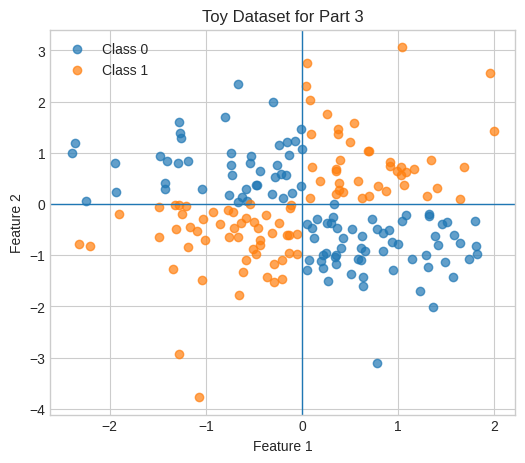

In [16]:

plt.figure(figsize=(6, 5))
plt.scatter(X[0, Y.flatten() == 0], X[1, Y.flatten() == 0], label='Class 0', alpha=0.7)
plt.scatter(X[0, Y.flatten() == 1], X[1, Y.flatten() == 1], label='Class 1', alpha=0.7)
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.title("Toy Dataset for Part 3")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()


### 1) Compare Activation Functions: ReLU vs Sigmoid

Below, the same network architecture is trained twice:

- hidden layers = `(8, 6)`
- learning rate = `0.1`
- epochs = `3000`

The only difference is the **hidden activation function**.


ReLU final loss: 0.022471310866473127
ReLU accuracy: 1.0
Sigmoid final loss: 0.636857208678671
Sigmoid accuracy: 0.615


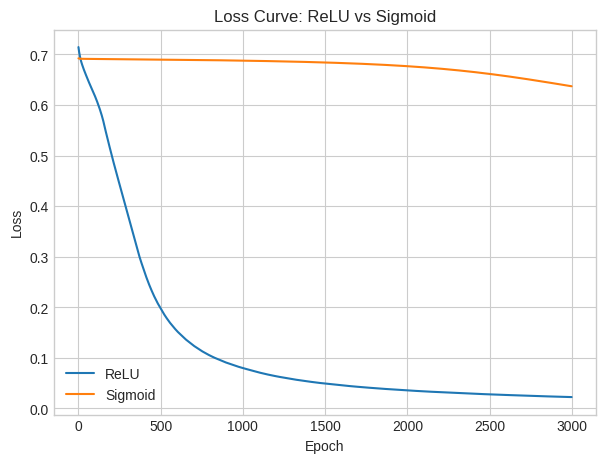

In [17]:

relu_result = train_mlp(X, Y, hidden_layers=(8, 6), hidden_activation='relu',
                        learning_rate=0.1, epochs=3000, seed=1)

sigmoid_result = train_mlp(X, Y, hidden_layers=(8, 6), hidden_activation='sigmoid',
                           learning_rate=0.1, epochs=3000, seed=1)

print("ReLU final loss:", relu_result['losses'][-1])
print("ReLU accuracy:", relu_result['accuracy'])
print("Sigmoid final loss:", sigmoid_result['losses'][-1])
print("Sigmoid accuracy:", sigmoid_result['accuracy'])

plt.figure(figsize=(7, 5))
plt.plot(relu_result['losses'], label='ReLU')
plt.plot(sigmoid_result['losses'], label='Sigmoid')
plt.title("Loss Curve: ReLU vs Sigmoid")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


#### Reflection: Activation Functions

In this experiment, **ReLU trained much better than sigmoid** on the same network and dataset.  
The ReLU model reduced the loss much more and reached higher accuracy.

A likely reason is that **sigmoid can shrink gradients**, especially when activations move toward 0 or 1.  
When gradients become too small, weight updates also become very small, so learning slows down.  
ReLU usually keeps stronger gradients for positive values, which makes optimization more stable in deeper networks.


### 2) Compare Learning Rates

Now we keep the architecture fixed and only change the **learning rate**.  
This helps show how the step size affects convergence.


Learning rate = 0.01
  final loss: 0.5024066615312183
  accuracy: 0.76
Learning rate = 0.1
  final loss: 0.03571950111470059
  accuracy: 0.99
Learning rate = 1.0
  final loss: 0.0015967544680867917
  accuracy: 1.0


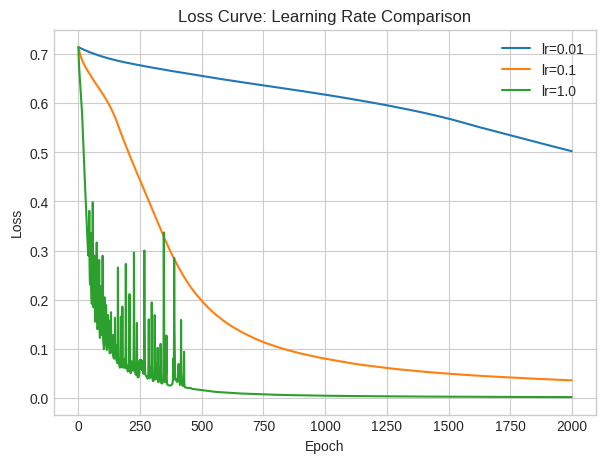

In [18]:

lr_values = [0.01, 0.1, 1.0]
lr_results = {}

for lr in lr_values:
    lr_results[lr] = train_mlp(
        X, Y,
        hidden_layers=(8, 6),
        hidden_activation='relu',
        learning_rate=lr,
        epochs=2000,
        seed=1
    )
    print(f"Learning rate = {lr}")
    print("  final loss:", lr_results[lr]['losses'][-1])
    print("  accuracy:", lr_results[lr]['accuracy'])

plt.figure(figsize=(7, 5))
for lr in lr_values:
    plt.plot(lr_results[lr]['losses'], label=f'lr={lr}')
plt.title("Loss Curve: Learning Rate Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


#### Reflection: Learning Rate

The **small learning rate (0.01)** improved the model slowly.  
The **moderate learning rate (0.1)** converged faster and more smoothly.  
In this toy example, a **larger learning rate (1.0)** still worked, but in more difficult problems a very large learning rate can make training unstable or cause the loss to jump around.

So, the learning rate controls how aggressively the model updates its weights.  
If it is too small, training is slow. If it is too large, optimization can become unstable.


### 3) Compare Network Depth

Next, we compare:

- **Shallow network:** 2 hidden layers → `(8, 6)`
- **Deeper network:** 3 hidden layers → `(8, 6, 4)`

We also look at how depth interacts with the choice of activation function.


Shallow ReLU final loss: 0.022471310866473127 accuracy: 1.0
Deep ReLU final loss: 0.0020391672173343013 accuracy: 1.0
Deep Sigmoid final loss: 0.6917929992419236 accuracy: 0.525


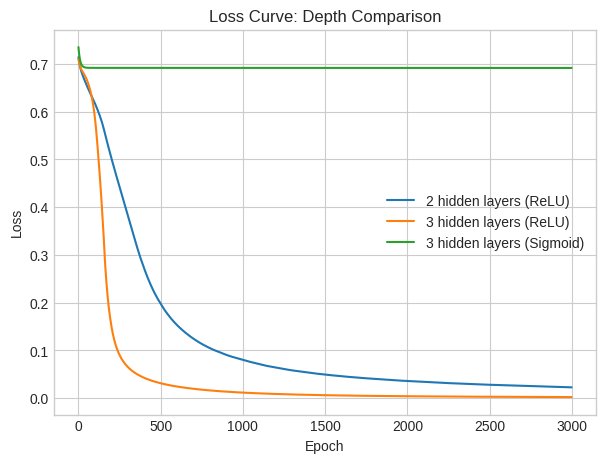

In [19]:

shallow_relu = train_mlp(X, Y, hidden_layers=(8, 6), hidden_activation='relu',
                         learning_rate=0.1, epochs=3000, seed=1)

deep_relu = train_mlp(X, Y, hidden_layers=(8, 6, 4), hidden_activation='relu',
                      learning_rate=0.1, epochs=3000, seed=1)

deep_sigmoid = train_mlp(X, Y, hidden_layers=(8, 6, 4), hidden_activation='sigmoid',
                         learning_rate=0.1, epochs=3000, seed=1)

print("Shallow ReLU final loss:", shallow_relu['losses'][-1], "accuracy:", shallow_relu['accuracy'])
print("Deep ReLU final loss:", deep_relu['losses'][-1], "accuracy:", deep_relu['accuracy'])
print("Deep Sigmoid final loss:", deep_sigmoid['losses'][-1], "accuracy:", deep_sigmoid['accuracy'])

plt.figure(figsize=(7, 5))
plt.plot(shallow_relu['losses'], label='2 hidden layers (ReLU)')
plt.plot(deep_relu['losses'], label='3 hidden layers (ReLU)')
plt.plot(deep_sigmoid['losses'], label='3 hidden layers (Sigmoid)')
plt.title("Loss Curve: Depth Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


### 4) Visualize Forward Flow of Activations and Backward Flow of Gradients

To keep the plots readable, we visualize the **final mean absolute activation values** and the **final mean absolute gradient sizes** for the deeper models.

- **Forward flow of activations** shows how much signal is passing through each layer.
- **Backward flow of gradients** shows how strong the learning signal is during backpropagation.


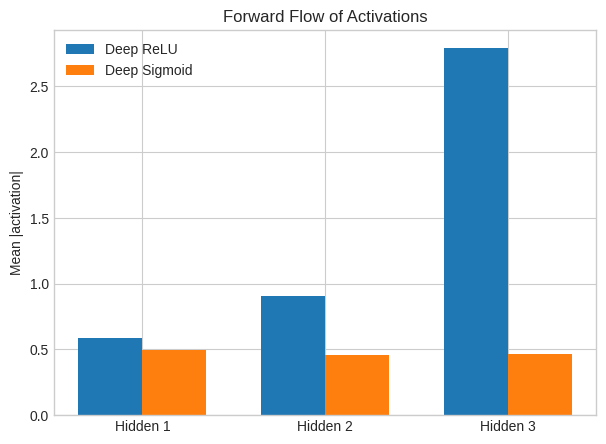

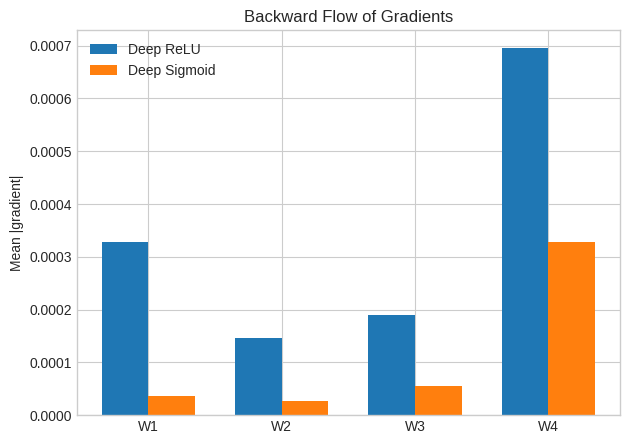

Deep ReLU gradient magnitudes: [0.00032881 0.00014546 0.00018961 0.00069451]
Deep Sigmoid gradient magnitudes: [3.58419777e-05 2.64986853e-05 5.58285990e-05 3.27849926e-04]


In [20]:

# Forward flow: mean absolute activations for hidden layers
relu_act = [float(np.mean(np.abs(deep_relu['cache'][f'A{i}']))) for i in range(1, 4)]
sigmoid_act = [float(np.mean(np.abs(deep_sigmoid['cache'][f'A{i}']))) for i in range(1, 4)]

layers_hidden = ['Hidden 1', 'Hidden 2', 'Hidden 3']
x = np.arange(len(layers_hidden))
width = 0.35

plt.figure(figsize=(7, 5))
plt.bar(x - width/2, relu_act, width, label='Deep ReLU')
plt.bar(x + width/2, sigmoid_act, width, label='Deep Sigmoid')
plt.title("Forward Flow of Activations")
plt.ylabel("Mean |activation|")
plt.xticks(x, layers_hidden)
plt.legend()
plt.show()

# Backward flow: mean absolute gradient sizes for each weight matrix
relu_grad = deep_relu['gradient_flow'][-1]
sigmoid_grad = deep_sigmoid['gradient_flow'][-1]

layers_grad = ['W1', 'W2', 'W3', 'W4']
x2 = np.arange(len(layers_grad))

plt.figure(figsize=(7, 5))
plt.bar(x2 - width/2, relu_grad, width, label='Deep ReLU')
plt.bar(x2 + width/2, sigmoid_grad, width, label='Deep Sigmoid')
plt.title("Backward Flow of Gradients")
plt.ylabel("Mean |gradient|")
plt.xticks(x2, layers_grad)
plt.legend()
plt.show()

print("Deep ReLU gradient magnitudes:", relu_grad)
print("Deep Sigmoid gradient magnitudes:", sigmoid_grad)


### 5) Reflection

#### How vanishing / exploding gradients affect deeper networks

In deeper networks, gradients must pass through more layers during backpropagation.  
If they become **too small**, earlier layers receive almost no learning signal. This is called the **vanishing gradient problem**.  
If they become **too large**, updates can become unstable, which is known as the **exploding gradient problem**.

In the experiment above, the **deep sigmoid network** showed much smaller gradient values in earlier layers.  
This is a clear sign that the gradient is weakening as it moves backward through the network.

#### The role of activation functions in gradient stability

Activation functions strongly affect gradient behavior.  
**Sigmoid** tends to squash values into a narrow range, and its derivative is often small.  
Because of this, repeated multiplication through many layers can shrink gradients quickly.

**ReLU**, on the other hand, usually preserves stronger gradients for positive inputs.  
That is one reason why ReLU often trains faster and more reliably in deeper networks.

### Overall conclusion (Talking Points)

From these experiments:

- **ReLU** was more effective than sigmoid on this task.
- A **moderate learning rate** gave stable and efficient training.
- Adding depth can increase model capacity, but it also makes optimization harder.
- Gradient flow is easier to maintain with **ReLU** than with **sigmoid** in deeper networks.


## 🔧 Optional Extension: XOR Classifier

Implement a simple XOR classifier using a NumPy MLP and compare it with a Keras model.


Prepare the XOR truth table as:

| x1 | x2 | y |
|---|---|---|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |


### Part A: NumPy Implementation


NumPy Predictions: [[0 1 1 0]]
Accuracy: 1.0


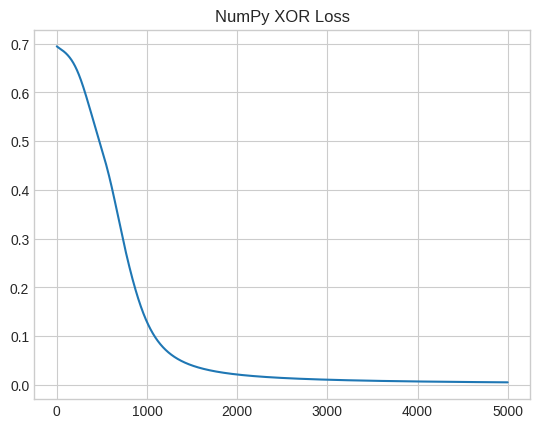

In [21]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]])
Y = np.array([[0, 1, 1, 0]])

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

def tanh(z):
    return np.tanh(z)

def tanh_derivative(a):
    return 1 - a**2

W1 = np.random.randn(4, 2) * 0.5
b1 = np.zeros((4, 1))

W2 = np.random.randn(1, 4) * 0.5
b2 = np.zeros((1, 1))

learning_rate = 0.1
epochs = 5000
m = X.shape[1]
losses = []

for epoch in range(epochs):
    Z1 = W1 @ X + b1
    A1 = tanh(Z1)

    Z2 = W2 @ A1 + b2
    A2 = sigmoid(Z2)

    epsilon = 1e-8
    loss = -np.mean(Y * np.log(A2 + epsilon) + (1 - Y) * np.log(1 - A2 + epsilon))
    losses.append(loss)

    dZ2 = A2 - Y
    dW2 = (1 / m) * dZ2 @ A1.T
    db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)

    dA1 = W2.T @ dZ2
    dZ1 = dA1 * tanh_derivative(A1)
    dW1 = (1 / m) * dZ1 @ X.T
    db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

preds = (A2 > 0.5).astype(int)
accuracy = np.mean(preds == Y)

print("NumPy Predictions:", preds)
print("Accuracy:", accuracy)

plt.plot(losses)
plt.title("NumPy XOR Loss")
plt.show()

### Part B: Keras Implementation

In [24]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X_keras = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=np.float32)
Y_keras = np.array([[0],[1],[1],[0]], dtype=np.float32)

model = Sequential([
    Dense(4, activation='tanh', input_shape=(2,)),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_keras, Y_keras, epochs=500, verbose=0)

loss, acc = model.evaluate(X_keras, Y_keras, verbose=0)
preds = (model.predict(X_keras) > 0.5).astype(int)

print("Keras Accuracy:", acc)
print("Predictions:", preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Keras Accuracy: 1.0
Predictions: [[0]
 [1]
 [1]
 [0]]


### Reflection

The NumPy model helps understand the learning process step by step, while Keras simplifies implementation. Both can solve XOR, but frameworks are more practical.